In [28]:
import os
os.environ["NUMBA_CACHE_DIR"] = "/Users/gretawette/Documents/Thesis/.numba_cache"

from bertopic import BERTopic

tm_rt = BERTopic.load(
    "/Users/gretawette/Documents/Thesis/BERTopic/outputs/rt_model",
    embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)
tm_ts = BERTopic.load(
    "/Users/gretawette/Documents/Thesis/BERTopic/outputs/ts_model",
    embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [29]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

In [31]:
rt_ids = [t for t in sorted(tm_rt.get_topics().keys()) if t != -1]
ts_ids = [t for t in sorted(tm_ts.get_topics().keys()) if t != -1]

rt_texts = [" ".join([w for w, _ in (tm_rt.get_topic(t) or [])[:15]]) for t in rt_ids]
ts_texts = [" ".join([w for w, _ in (tm_ts.get_topic(t) or [])[:15]]) for t in ts_ids]


rt_emb = encoder.encode(rt_texts, normalize_embeddings=True)
ts_emb = encoder.encode(ts_texts, normalize_embeddings=True)

sim_matrix = cosine_similarity(rt_emb, ts_emb)
assert sim_matrix.shape == (len(rt_ids), len(ts_ids))


In [33]:
rt_info = tm_rt.get_topic_info()
ts_info = tm_ts.get_topic_info()


In [34]:
# Option B: top 25 by Count
rt_ids = (rt_info[rt_info["Topic"] != -1]
          .nlargest(25, "Count")["Topic"].tolist())
ts_ids = (ts_info[ts_info["Topic"] != -1]
          .nlargest(25, "Count")["Topic"].tolist())


In [35]:
rt_texts = [" ".join([w for w, _ in (tm_rt.get_topic(t) or [])[:15]]) for t in rt_ids]
ts_texts = [" ".join([w for w, _ in (tm_ts.get_topic(t) or [])[:15]]) for t in ts_ids]

rt_emb = encoder.encode(rt_texts, normalize_embeddings=True)
ts_emb = encoder.encode(ts_texts, normalize_embeddings=True)

sim_matrix = cosine_similarity(rt_emb, ts_emb)
print(sim_matrix.shape)  # should be (25, 25)


(25, 25)


(25, 25)


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,0.938,0.286,0.126,0.152,0.165,0.277,0.164,0.137,0.285,0.150,...,0.074,0.001,0.236,0.035,0.572,0.233,0.069,0.117,0.121,0.258
1,0.033,0.182,0.897,0.144,0.120,0.311,0.043,0.083,0.206,0.399,...,0.211,0.011,0.270,0.018,0.388,0.193,0.045,0.178,0.118,0.256
2,0.279,0.713,0.301,0.079,0.163,0.395,0.238,0.089,0.591,0.091,...,-0.075,-0.056,0.393,0.106,0.302,0.152,-0.013,-0.045,0.054,0.528
3,0.135,-0.082,0.110,0.172,-0.064,-0.025,0.035,0.886,-0.054,0.060,...,0.044,0.015,0.075,0.023,0.016,0.162,0.022,0.116,0.086,-0.050
4,0.145,0.268,0.283,0.098,0.005,0.461,0.120,0.092,0.214,0.218,...,0.030,0.030,0.208,0.106,0.269,0.153,0.135,0.186,0.215,0.217
5,0.238,0.112,0.109,-0.025,0.072,0.186,0.144,0.107,0.178,0.101,...,-0.014,0.197,0.108,0.159,0.230,0.113,0.134,0.190,0.068,0.209
6,0.105,0.039,0.143,0.514,-0.034,-0.010,0.121,-0.011,-0.010,0.009,...,0.201,0.321,-0.023,0.064,0.050,-0.013,0.049,0.104,0.027,0.190
7,0.163,0.558,0.240,0.407,0.072,0.439,0.281,0.006,0.544,0.167,...,0.179,0.225,0.203,0.214,0.219,0.160,0.102,0.093,0.206,0.851
8,0.105,0.145,0.109,0.085,0.008,0.071,0.026,0.037,0.203,0.146,...,0.086,0.172,0.055,0.301,0.048,0.183,0.079,0.228,0.135,0.310
9,0.197,0.575,0.265,-0.071,0.140,0.465,0.198,-0.112,0.733,0.156,...,-0.145,-0.024,0.384,0.353,0.397,0.337,0.042,0.207,0.161,0.479


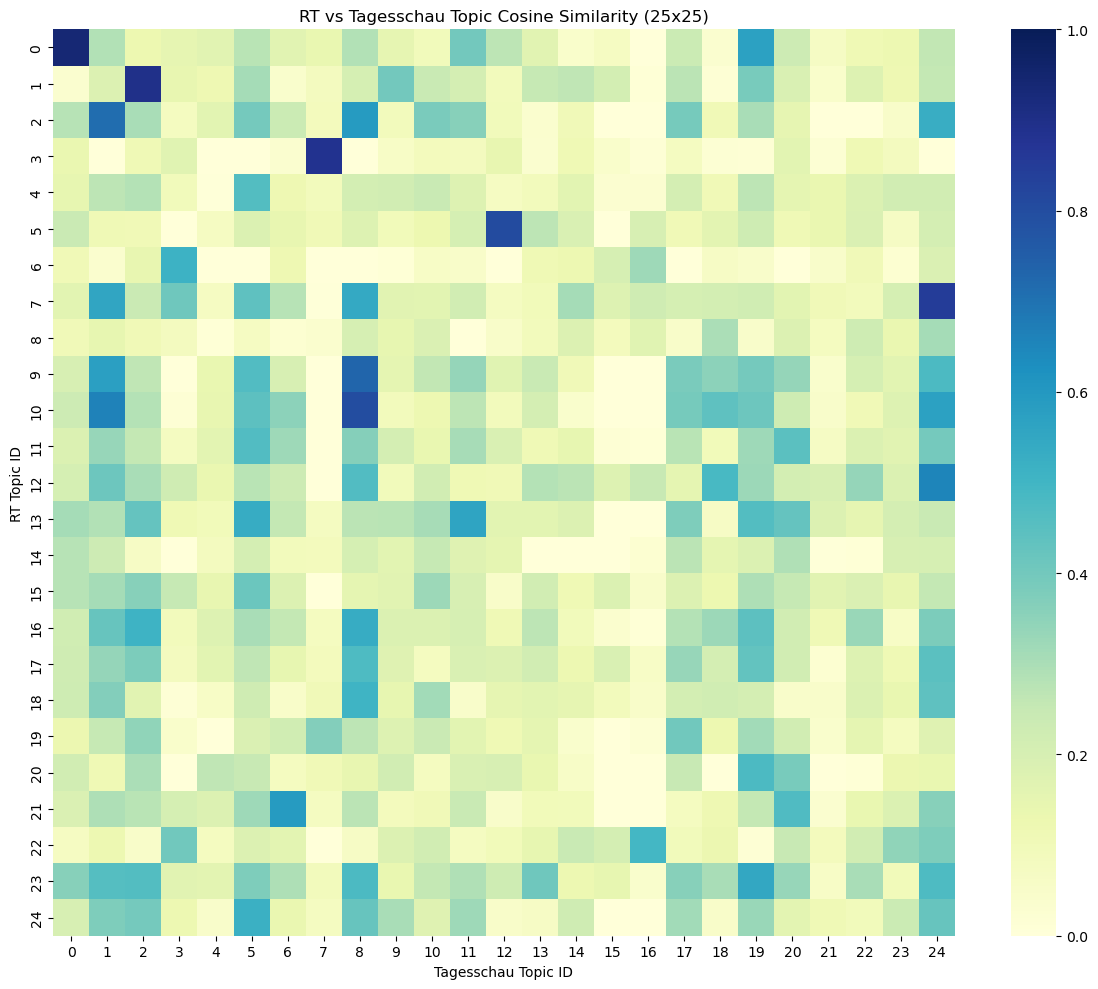

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
sim_df = pd.DataFrame(sim_matrix, index=rt_ids, columns=ts_ids)

print(sim_matrix.shape)
display(sim_df.round(3))

# 6) Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(sim_df, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("RT vs Tagesschau Topic Cosine Similarity (25x25)")
plt.xlabel("Tagesschau Topic ID")
plt.ylabel("RT Topic ID")
plt.tight_layout()
plt.show()

,0: 0_israel_hamas_gazastreifen_gaza,1: 1_ukraine_putin_selenskyj_trump,2: 2_venezuela_maduro_trump_venezuelas,3: 3_dax_dollar_punkten_anleger,4: 4_patienten_medikamente_warken_virus,5: 5_bolsonaro_babis_chp_partei,6: 6_bundesanwaltschaft_gericht_haft_prozess,7: 7_china_xi_trump_peking,8: 8_ukraine_russland_russischen_ukrainische,9: 9_überschwemmungen_ums leben_philippinen_ums,...,15: 15_lebensmittel_fleisch_tonnen_preise,16: 16_co2_strom_reiche_energiewende,17: 17_taliban_afghanistan_afghanen_pakistan,18: 18_bahn_palla_db_schnieder,19: 19_syrien_al_scharaa_syrischen,20: 20_gewalt_frauen_opfer_polizei,21: 21_grad_klimawandel_temperaturen_sommer,22: 22_wohnungen_wohnung_mieten_wohnraum,23: 23_eu_dobrindt_grenzkontrollen_asylbewerber,24: 24_eu_russischen_russland_ukraine
0: 0_israel_gaza_hamas_israelischen,0.938,0.286,0.126,0.152,0.165,0.277,0.164,0.137,0.285,0.150,...,0.074,0.001,0.236,0.035,0.572,0.233,0.069,0.117,0.121,0.258
1: 1_venezuela_maduro_venezuelas_venezolanischen,0.033,0.182,0.897,0.144,0.120,0.311,0.043,0.083,0.206,0.399,...,0.211,0.011,0.270,0.018,0.388,0.193,0.045,0.178,0.118,0.256
2: 2_putin_selenskij_trumps_washington,0.279,0.713,0.301,0.079,0.163,0.395,0.238,0.089,0.591,0.091,...,-0.075,-0.056,0.393,0.106,0.302,0.152,-0.013,-0.045,0.054,0.528
3: 3_china_taiwan_peking_chinas,0.135,-0.082,0.110,0.172,-0.064,-0.025,0.035,0.886,-0.054,0.060,...,0.044,0.015,0.075,0.023,0.016,0.162,0.022,0.116,0.086,-0.050
4: 4_afd_bsw_partei_spd,0.145,0.268,0.283,0.098,0.005,0.461,0.120,0.092,0.214,0.218,...,0.030,0.030,0.208,0.106,0.269,0.153,0.135,0.186,0.215,0.217
5: 5_drohnen_flugzeuge_flugzeug_luftraum,0.238,0.112,0.109,-0.025,0.072,0.186,0.144,0.107,0.178,0.101,...,-0.014,0.197,0.108,0.159,0.230,0.113,0.134,0.190,0.068,0.209
6: 6_dollar_us dollar_gold_pro,0.105,0.039,0.143,0.514,-0.034,-0.010,0.121,-0.011,-0.010,0.009,...,0.201,0.321,-0.023,0.064,0.050,-0.013,0.049,0.104,0.027,0.190
7: 7_vermögenswerte_milliarden_milliarden euro_euro,0.163,0.558,0.240,0.407,0.072,0.439,0.281,0.006,0.544,0.167,...,0.179,0.225,0.203,0.214,0.219,0.160,0.102,0.093,0.206,0.851
8: 8_kommission_leyen_schweizer_schweiz,0.105,0.145,0.109,0.085,0.008,0.071,0.026,0.037,0.203,0.146,...,0.086,0.172,0.055,0.301,0.048,0.183,0.079,0.228,0.135,0.310
9: 9_stadt_streitkräfte_truppen_ukrainische,0.197,0.575,0.265,-0.071,0.140,0.465,0.198,-0.112,0.733,0.156,...,-0.145,-0.024,0.384,0.353,0.397,0.337,0.042,0.207,0.161,0.479


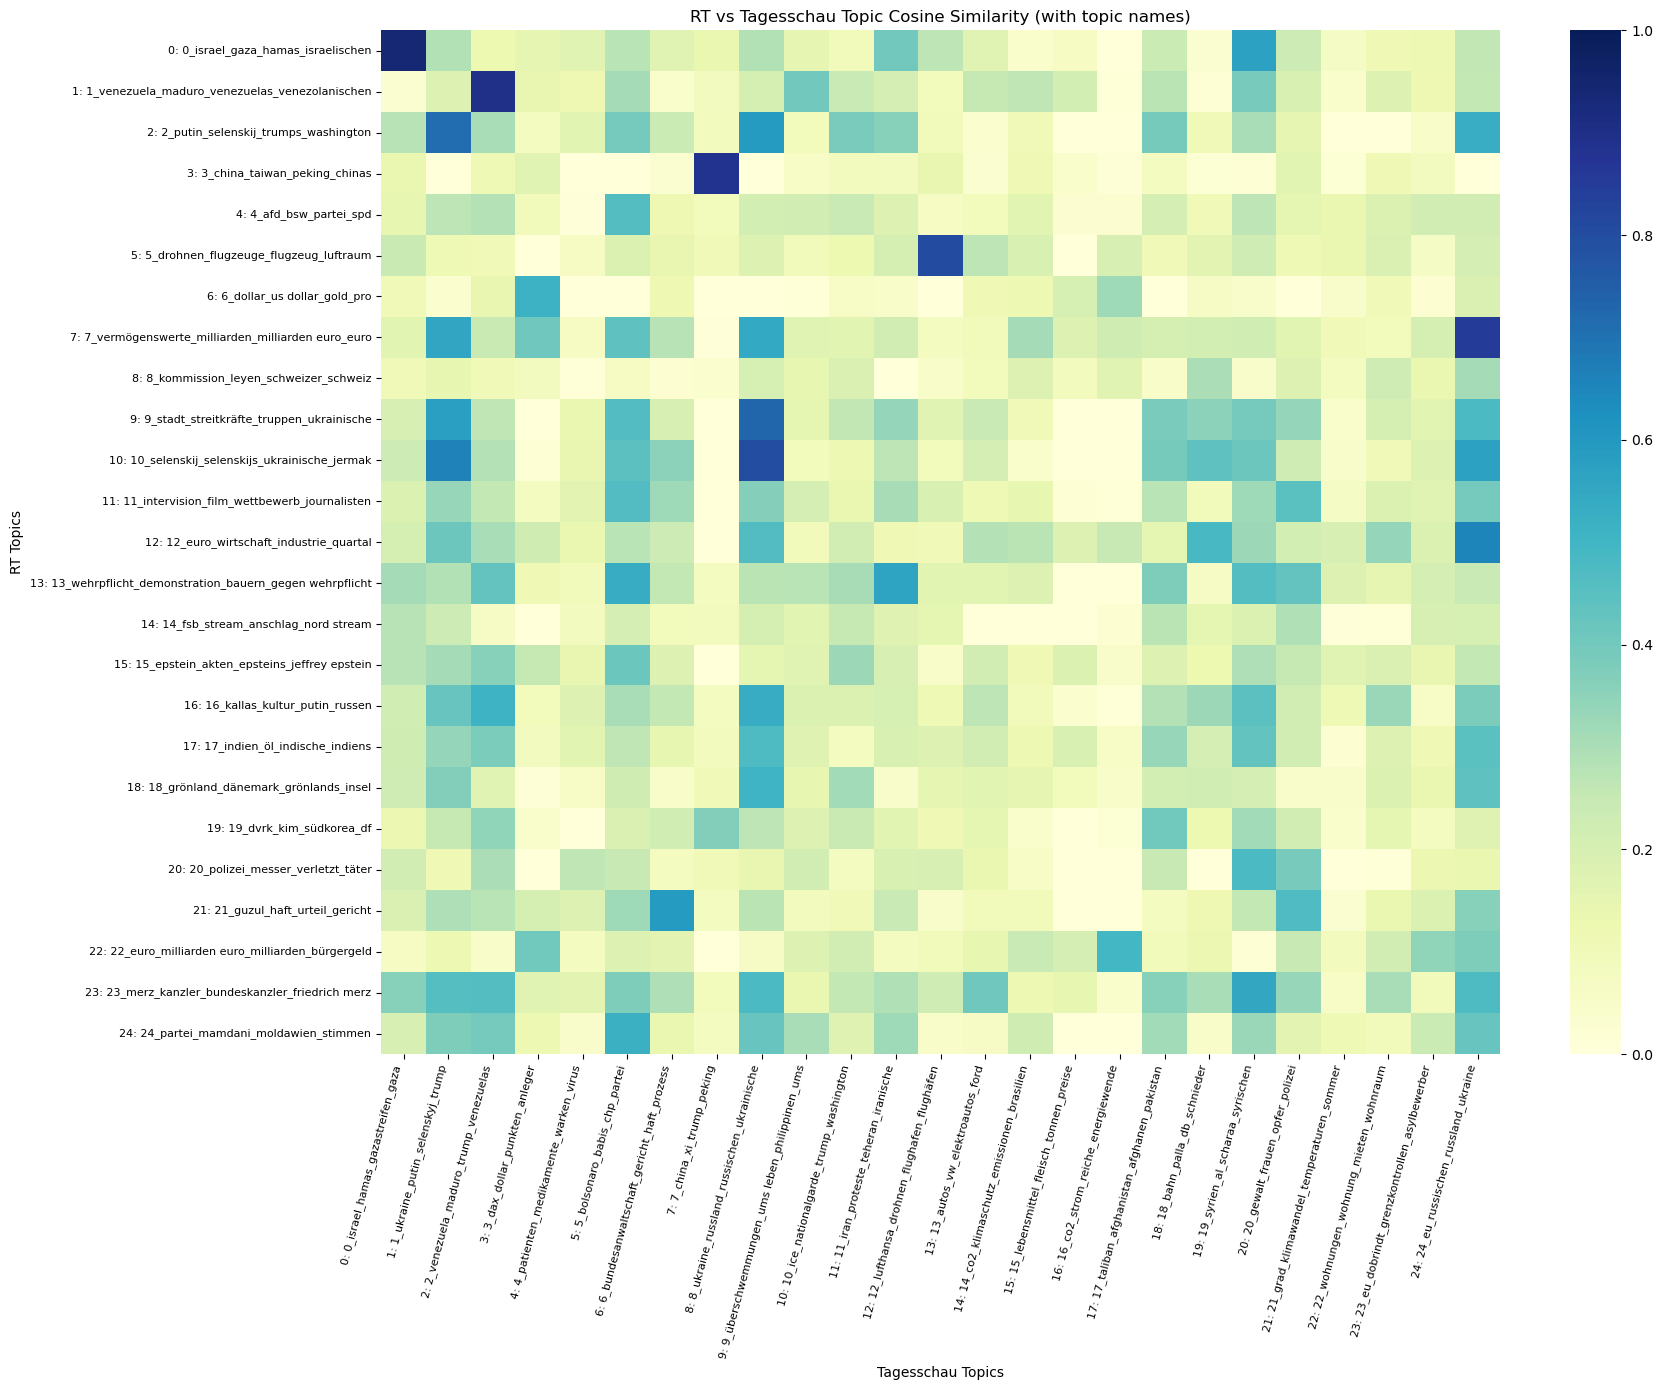

In [40]:
# Add readable topic names to matrix labels
rt_name_map = dict(zip(rt_info["Topic"], rt_info["Name"]))
ts_name_map = dict(zip(ts_info["Topic"], ts_info["Name"]))

rt_labels = [f"{t}: {rt_name_map.get(t, str(t))}" for t in rt_ids]
ts_labels = [f"{t}: {ts_name_map.get(t, str(t))}" for t in ts_ids]

sim_df_named = pd.DataFrame(sim_matrix, index=rt_labels, columns=ts_labels)
display(sim_df_named.round(3))

plt.figure(figsize=(18, 14))
sns.heatmap(sim_df_named, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("RT vs Tagesschau Topic Cosine Similarity (with topic names)")
plt.xlabel("Tagesschau Topics")
plt.ylabel("RT Topics")
plt.xticks(rotation=75, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


In [41]:
# Top topic pairs by cosine similarity
pairs = []
for i, rt_id in enumerate(rt_ids):
    for j, ts_id in enumerate(ts_ids):
        pairs.append({
            "RT Topic": rt_id,
            "RT Name": rt_name_map.get(rt_id, str(rt_id)),
            "Tagesschau Topic": ts_id,
            "Tagesschau Name": ts_name_map.get(ts_id, str(ts_id)),
            "Similarity": float(sim_matrix[i, j]),
        })

pairs_df = pd.DataFrame(pairs).sort_values("Similarity", ascending=False).reset_index(drop=True)

# show top N pairs
top_n = 30
display(pairs_df.head(top_n).style.format({"Similarity": "{:.3f}"}))


,RT Topic,RT Name,Tagesschau Topic,Tagesschau Name,Similarity
0,0,0_israel_gaza_hamas_israelischen,0,0_israel_hamas_gazastreifen_gaza,0.938
1,1,1_venezuela_maduro_venezuelas_venezolanischen,2,2_venezuela_maduro_trump_venezuelas,0.897
2,3,3_china_taiwan_peking_chinas,7,7_china_xi_trump_peking,0.886
3,7,7_vermögenswerte_milliarden_milliarden euro_euro,24,24_eu_russischen_russland_ukraine,0.851
4,5,5_drohnen_flugzeuge_flugzeug_luftraum,12,12_lufthansa_drohnen_flughafen_flughäfen,0.805
5,10,10_selenskij_selenskijs_ukrainische_jermak,8,8_ukraine_russland_russischen_ukrainische,0.799
6,9,9_stadt_streitkräfte_truppen_ukrainische,8,8_ukraine_russland_russischen_ukrainische,0.733
7,2,2_putin_selenskij_trumps_washington,1,1_ukraine_putin_selenskyj_trump,0.713
8,10,10_selenskij_selenskijs_ukrainische_jermak,1,1_ukraine_putin_selenskyj_trump,0.662
9,12,12_euro_wirtschaft_industrie_quartal,24,24_eu_russischen_russland_ukraine,0.655


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,RT Topic,Tagesschau Topic,Cosine Similarity
0,0,0,0.938019
9,18,26,0.906127
1,1,2,0.896784
2,3,7,0.886032
12,33,51,0.879375
8,15,47,0.834299
14,53,19,0.808912
16,56,24,0.805157
4,5,12,0.804758
11,31,44,0.779050


RT topics: 63
Tagesschau topics: 59
Common topics (cosine >= 0.7): 17


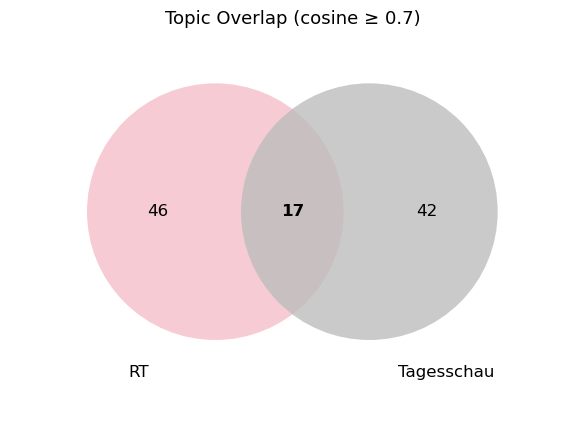

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.optimize import linear_sum_assignment

# --- Inputs ---
threshold = 0.70
top_k_words = 15  # words per topic for embedding text

# Use existing notebook variables if result_* dicts are missing
if "result_rt" in globals() and isinstance(result_rt, dict) and "topic_model" in result_rt:
    tm_rt = result_rt["topic_model"]

if "result_ts" not in globals():
    result_ts = {"topic_model": tm_ts}
tm_ts = result_ts["topic_model"]

# --- 1) Get ALL topics (exclude outlier -1) ---
rt_info = tm_rt.get_topic_info()
ts_info = tm_ts.get_topic_info()

rt_ids = rt_info.loc[rt_info["Topic"] != -1, "Topic"].astype(int).tolist()
ts_ids = ts_info.loc[ts_info["Topic"] != -1, "Topic"].astype(int).tolist()

# --- 2) Build topic texts ---
rt_texts = [" ".join([w for w, _ in (tm_rt.get_topic(t) or [])[:top_k_words]]) for t in rt_ids]
ts_texts = [" ".join([w for w, _ in (tm_ts.get_topic(t) or [])[:top_k_words]]) for t in ts_ids]

# --- 3) Encode + cosine matrix ---
encoder = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
rt_emb = encoder.encode(rt_texts, normalize_embeddings=True)
ts_emb = encoder.encode(ts_texts, normalize_embeddings=True)

sim_matrix = cosine_similarity(rt_emb, ts_emb)  # shape: (n_rt, n_ts)

# --- 4) One-to-one matching + threshold (prevents double-counting overlap) ---
r_idx, c_idx = linear_sum_assignment(-sim_matrix)  # maximize total similarity
matched_scores = sim_matrix[r_idx, c_idx]
keep = matched_scores >= threshold

common_rt = [rt_ids[i] for i in r_idx[keep]]
common_ts = [ts_ids[j] for j in c_idx[keep]]
common_scores = matched_scores[keep]

n_rt = len(rt_ids)
n_ts = len(ts_ids)
n_common = len(common_rt)
n_rt_only = n_rt - n_common
n_ts_only = n_ts - n_common

# Optional: table of common pairs
common_pairs = pd.DataFrame({
    "RT Topic": common_rt,
    "Tagesschau Topic": common_ts,
    "Cosine Similarity": common_scores
}).sort_values("Cosine Similarity", ascending=False)
display(common_pairs.head(20))

print(f"RT topics: {n_rt}")
print(f"Tagesschau topics: {n_ts}")
print(f"Common topics (cosine >= {threshold}): {n_common}")

# --- 5) Bubble overlap plot ---
fig, ax = plt.subplots(figsize=(8, 5))

left_center = (-0.6, 0)
right_center = (0.6, 0)
radius = 1.0

left_circle = Circle(left_center, radius, color="#f4b6c2", alpha=0.7, lw=0)
right_circle = Circle(right_center, radius, color="#bdbdbd", alpha=0.8, lw=0)
ax.add_patch(left_circle)
ax.add_patch(right_circle)

# counts
ax.text(-1.05, 0, str(n_rt_only), ha="center", va="center", fontsize=12)
ax.text(0.00, 0, str(n_common), ha="center", va="center", fontsize=12, fontweight="bold")
ax.text(1.05, 0, str(n_ts_only), ha="center", va="center", fontsize=12)

# labels
ax.text(-1.2, -1.25, "RT", ha="center", va="center", fontsize=12)
ax.text(1.2, -1.25, "Tagesschau", ha="center", va="center", fontsize=12)

ax.set_title(f"Topic Overlap (cosine ≥ {threshold})", fontsize=13)
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-1.6, 1.4)
ax.set_aspect("equal")
ax.axis("off")
plt.show()


In [10]:
len(rt_embeddings), len(ts_embeddings)

(64, 59)